In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data/ecommerce_sales.csv")

print(df)

    Order_ID  Order_Date Customer_Name  Gender  Age       City     Category  \
0       1001  2026-01-05         Rahul    Male   24      Delhi  Electronics   
1       1002  2026-01-08         Priya  Female   28     Mumbai  Electronics   
2       1003  2026-01-15          Amit    Male   32  Bangalore    Furniture   
3       1004  2026-01-20         Sneha  Female   26      Delhi     Clothing   
4       1005  2026-02-02         Karan    Male   35       Pune  Electronics   
5       1006  2026-02-10          Neha  Female   23     Mumbai     Clothing   
6       1007  2026-02-18         Rohit    Male   29      Delhi    Furniture   
7       1008  2026-02-25        Anjali  Female   31  Bangalore  Electronics   
8       1009  2026-03-03         Vikas    Male   27       Pune     Clothing   
9       1010  2026-03-08         Pooja  Female   25      Delhi  Electronics   
10      1011  2026-03-15         Arjun    Male   38     Mumbai    Furniture   
11      1012  2026-03-20         Meera  Female   30 

In [5]:
print(df.head())

   Order_ID  Order_Date Customer_Name  Gender  Age       City     Category  \
0      1001  2026-01-05         Rahul    Male   24      Delhi  Electronics   
1      1002  2026-01-08         Priya  Female   28     Mumbai  Electronics   
2      1003  2026-01-15          Amit    Male   32  Bangalore    Furniture   
3      1004  2026-01-20         Sneha  Female   26      Delhi     Clothing   
4      1005  2026-02-02         Karan    Male   35       Pune  Electronics   

  Product  Quantity  Unit_Price Payment_Mode  Discount  Rating  
0  Laptop         1       55000          UPI         5     4.5  
1  Mobile         2       30000  Credit Card        10     4.2  
2   Chair         4        5000         Cash         5     4.0  
3  Jacket         2        3500          UPI        15     4.4  
4  Tablet         1       25000   Debit Card         8     4.1  


In [6]:
print(df.shape)

(20, 13)


In [7]:
print(df.isnull().sum())

Order_ID         0
Order_Date       0
Customer_Name    0
Gender           0
Age              0
City             0
Category         0
Product          0
Quantity         0
Unit_Price       0
Payment_Mode     0
Discount         0
Rating           0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df = df.drop_duplicates()

In [10]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"]
)

In [11]:
df["Gross_Sales"] = (
    df["Quantity"] *
    df["Unit_Price"]
)
df["Discount_Amount"] = (
    df["Gross_Sales"] *
    df["Discount"] / 100
)
df["Revenue"] = (
    df["Gross_Sales"] -
    df["Discount_Amount"]
)

In [12]:
print(
    df[
        [
            "Product",
            "Quantity",
            "Unit_Price",
            "Discount",
            "Revenue"
        ]
    ]
)

       Product  Quantity  Unit_Price  Discount  Revenue
0       Laptop         1       55000         5  52250.0
1       Mobile         2       30000        10  54000.0
2        Chair         4        5000         5  19000.0
3       Jacket         2        3500        15   5950.0
4       Tablet         1       25000         8  23000.0
5        Shoes         2        4000        10   7200.0
6        Table         1       12000         5  11400.0
7   Headphones         3        3000        12   7920.0
8        Shirt         5        1500         5   7125.0
9       Laptop         1       55000        10  49500.0
10        Sofa         1       35000         7  32550.0
11       Dress         2        4500        10   8100.0
12      Mobile         1       30000         5  28500.0
13       Chair         6        5000         8  27600.0
14      Tablet         2       25000        10  45000.0
15       Shoes         3        4000         5  11400.0
16       Table         2       12000         5  

In [13]:
total_revenue = np.sum(df["Revenue"])

print("Total Revenue:", total_revenue)

Total Revenue: 480775.0


In [14]:
max_order = np.max(df["Revenue"])

print("Highest Order Value:", max_order)

Highest Order Value: 54000.0


In [15]:
average_revenue = np.mean(df["Revenue"])

print("Average Revenue:", average_revenue)

Average Revenue: 24038.75


In [16]:
min_order = np.min(df["Revenue"])

print("Lowest Order Value:", min_order)

Lowest Order Value: 5950.0


In [17]:
total_revenue = df["Revenue"].sum()

print(
    "Total Revenue:",
    total_revenue
)

Total Revenue: 480775.0


In [18]:
total_quantity = df["Quantity"].sum()

print(
    "Total Quantity Sold:",
    total_quantity
)

Total Quantity Sold: 50


In [19]:
average_order = df["Revenue"].mean()

print(
    "Average Order Value:",
    average_order
)

Average Order Value: 24038.75


In [20]:
category_sales = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics    319370.0
Furniture      113350.0
Clothing        48055.0
Name: Revenue, dtype: float64


In [21]:
product_quantity = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(product_quantity)

Product
Shirt         11
Chair         10
Headphones     7
Shoes          5
Tablet         3
Mobile         3
Laptop         3
Table          3
Dress          2
Jacket         2
Sofa           1
Name: Quantity, dtype: int64


In [22]:
city_sales = (
    df.groupby("City")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(city_sales)

City
Delhi        167280.0
Mumbai       132150.0
Pune         123525.0
Bangalore     57820.0
Name: Revenue, dtype: float64


In [23]:
payment_count = (
    df["Payment_Mode"]
      .value_counts()
)

print(payment_count)

Payment_Mode
UPI            8
Credit Card    6
Cash           3
Debit Card     3
Name: count, dtype: int64


In [24]:
average_rating = df["Rating"].mean()

print(
    "Average Rating:",
    average_rating
)

Average Rating: 4.32


In [25]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Male      10
Female    10
Name: count, dtype: int64


In [26]:
df["Month"] = (
    df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

print(monthly_sales)

Month
2026-01    131200.0
2026-02     49520.0
2026-03     97275.0
2026-04    112500.0
2026-05     90280.0
Name: Revenue, dtype: float64


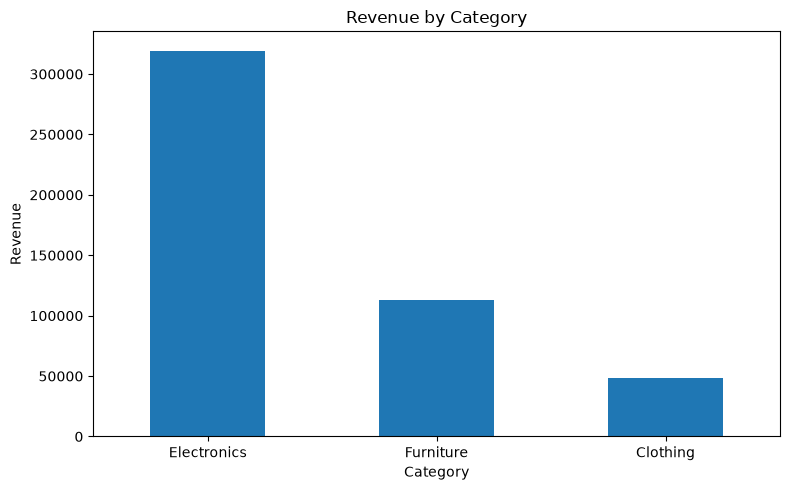

In [27]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

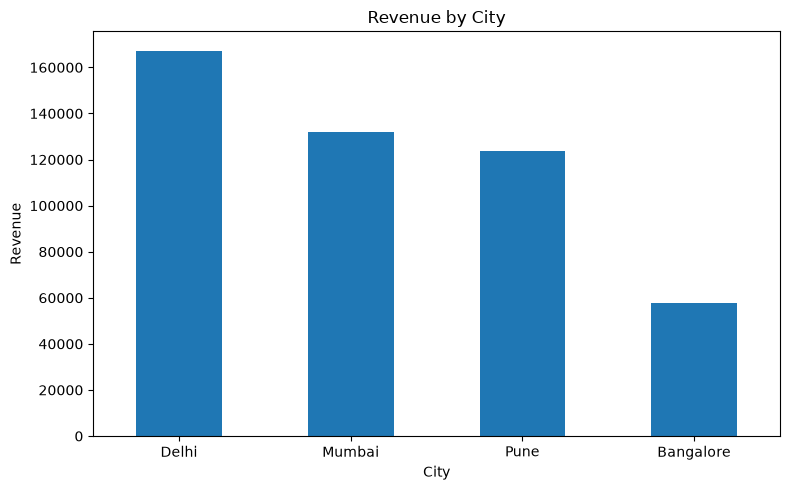

In [28]:
city_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

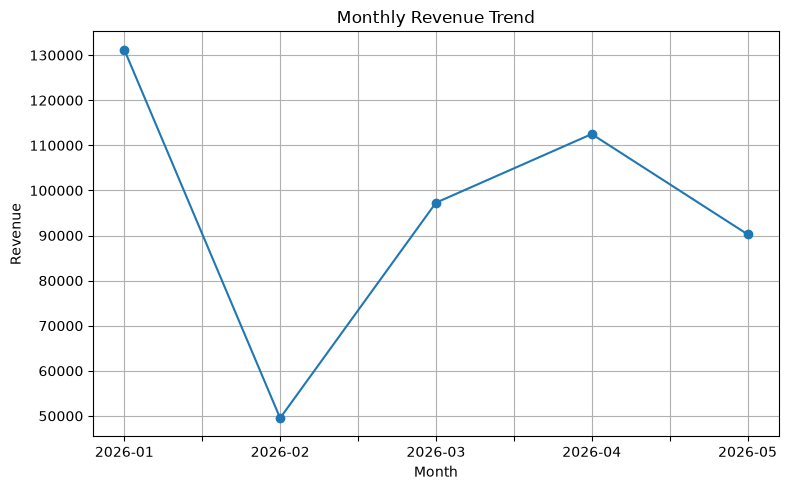

In [29]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid()

plt.tight_layout()

plt.show()

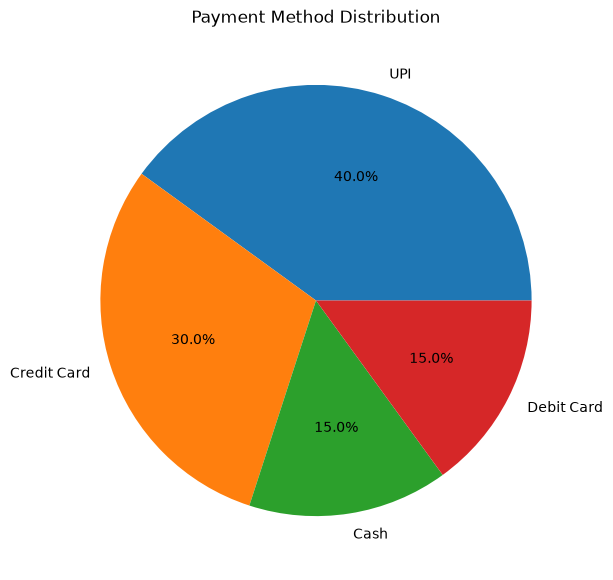

In [30]:
payment_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

In [31]:
customer_revenue = (
    df.groupby("Customer_Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(customer_revenue)

Customer_Name
Priya      54000.0
Rahul      52250.0
Pooja      49500.0
Nisha      48400.0
Manish     45000.0
Arjun      32550.0
Varun      28500.0
Simran     27600.0
Karan      23000.0
Aditya     22800.0
Amit       19000.0
Rohit      11400.0
Riya       11400.0
Kavita     10800.0
Saurabh     8280.0
Meera       8100.0
Anjali      7920.0
Neha        7200.0
Vikas       7125.0
Sneha       5950.0
Name: Revenue, dtype: float64


In [32]:
top_customers = customer_revenue.head(5)

print(top_customers)

Customer_Name
Priya     54000.0
Rahul     52250.0
Pooja     49500.0
Nisha     48400.0
Manish    45000.0
Name: Revenue, dtype: float64


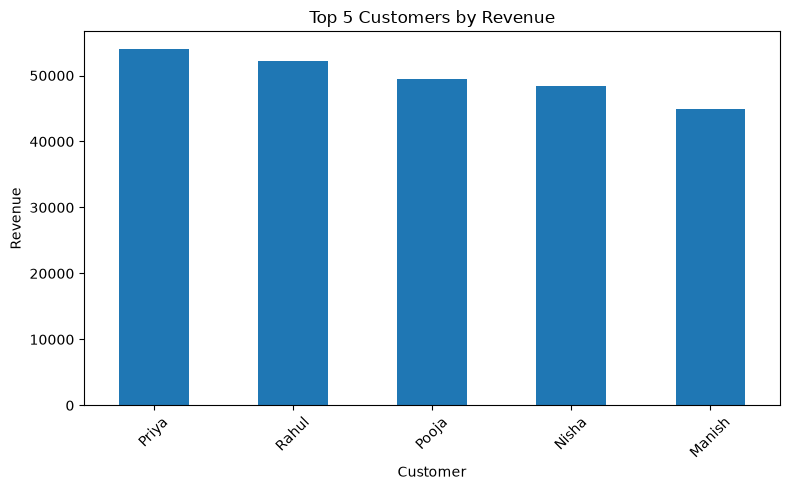

In [33]:
top_customers.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Top 5 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [34]:
bins = [0, 18, 25, 35, 50, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-50",
    "50+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [35]:
age_group_sales = (
    df.groupby(
        "Age_Group",
        observed=True
    )["Revenue"]
    .sum()
)

print(age_group_sales)

Age_Group
18-25    119750.0
26-35    235075.0
36-50    125950.0
Name: Revenue, dtype: float64


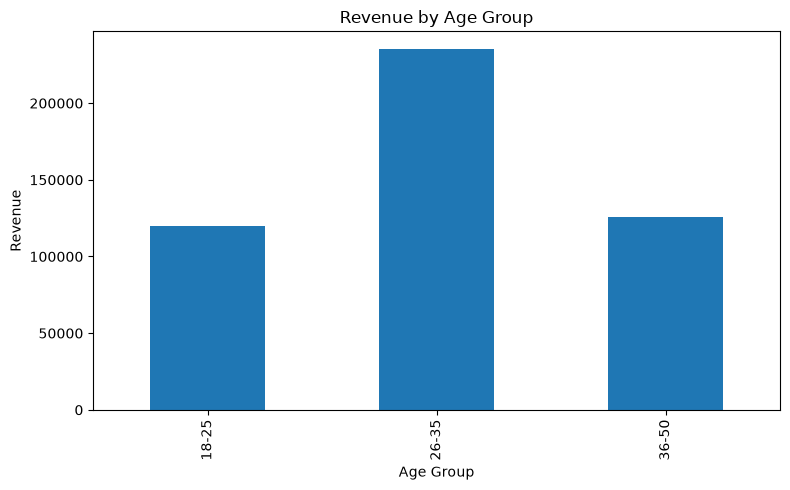

In [36]:
age_group_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [37]:
product_summary = (
    df.groupby("Product")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum"),
          Average_Rating=("Rating", "mean")
      )
      .sort_values(
          "Total_Revenue",
          ascending=False
      )
)

print(product_summary)

            Total_Quantity  Total_Revenue  Average_Rating
Product                                                  
Laptop                   3       150150.0        4.733333
Mobile                   3        82500.0        4.150000
Tablet                   3        68000.0        4.050000
Chair                   10        46600.0        4.100000
Table                    3        34200.0        4.000000
Sofa                     1        32550.0        4.300000
Headphones               7        18720.0        4.700000
Shoes                    5        18600.0        4.600000
Shirt                   11        15405.0        3.900000
Dress                    2         8100.0        4.500000
Jacket                   2         5950.0        4.400000


In [38]:
correlation = df[
    [
        "Age",
        "Quantity",
        "Unit_Price",
        "Discount",
        "Rating",
        "Revenue"
    ]
].corr()

print(correlation)

                 Age  Quantity  Unit_Price  Discount    Rating   Revenue
Age         1.000000 -0.147271    0.162629  0.041390 -0.278682  0.249533
Quantity   -0.147271  1.000000   -0.654974 -0.090147 -0.300199 -0.442102
Unit_Price  0.162629 -0.654974    1.000000  0.012719  0.323239  0.884747
Discount    0.041390 -0.090147    0.012719  1.000000  0.506218  0.006117
Rating     -0.278682 -0.300199    0.323239  0.506218  1.000000  0.157878
Revenue     0.249533 -0.442102    0.884747  0.006117  0.157878  1.000000


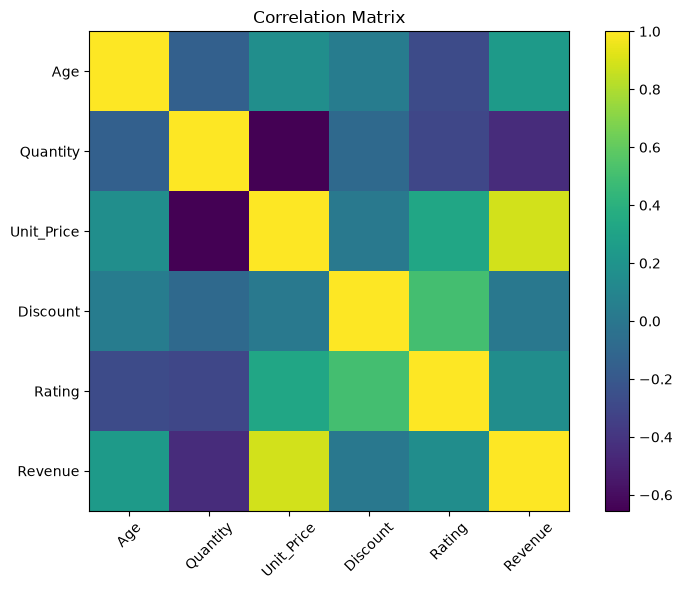

In [39]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()